In [3]:
#Bibliotecas
import pandas as pd
import polars as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import re

In [4]:
# Lista para alocar os dados da contagem de partículas
particulas = []

# Função para contar a quantidade de partículas em cada linha TRIG
def contar_particulas(evento):
    contagem = {}
    for linha in evento:
        partes = linha.split()
        if partes[0].startswith("TRIG"):
            contagem[partes[0]] = len(partes) - 1  
    return contagem

# Função para processar o arquivo e contar as partículas em cada evento
def contar_particulas_em_eventos(nome_arquivo):
    with open(nome_arquivo, 'r') as arquivo:
        linhas = arquivo.readlines()
    
    eventos = []
    evento_atual = []
    
    for linha in linhas:
        if linha.startswith("EVTE"):
            eventos.append(evento_atual)
            evento_atual = []
        evento_atual.append(linha)
    
    # Contagem da quantidade de partículas em cada linha TRIG em cada evento
    for i, evento in enumerate(eventos):
        contagem = contar_particulas(evento)
        #print(f"Evento {i + 1}:")
        for linha_trig, quantidade in contagem.items():
            #print(f"{linha_trig}: {quantidade} partículas")
            particulas.append(contagem)

if __name__ == "__main__":
    arquivo = "iron4.64E15"  
    contar_particulas_em_eventos(arquivo)


In [5]:
x1 = [0,346]
x2 = [-400,-346]
x3 = [400,-346]

r1 = (x1[0]**2+x1[1]**2)**0.5
r2 = (x2[0]**2+x2[1]**2)**0.5
r3 = (x3[0]**2+x3[1]**2)**0.5

trig1 = []
trig2 = []
trig3 = []

#type(particulas[20])

In [6]:
trigs = []
for i in particulas:
    trigs_aux = list(i.values())
    trigs.append(trigs_aux)

In [7]:
for i in range(0,len(trigs),3):
    sublista = trigs[i]
    trig1.append(sublista[0])

In [8]:
for i in range(0,len(trigs),3):
    sublista = trigs[i]
    trig2.append(sublista[1])

In [9]:
for i in range(0,len(trigs),3):
    sublista = trigs[i]
    trig3.append(sublista[2])

In [10]:
x_b = []
y_b = []

for i in range(len(trig1)):
        numerator = (trig1[i]*x1[0]+trig2[i]*x2[0]+trig3[i]*x3[0])
        demoninator = (trig1[i]+trig2[i]+trig3[i])
        numerator1 = (trig1[i]*x1[1]+trig2[i]*x2[1]+trig3[i]*x3[1])

        if demoninator == 0:
                x_b.append(0)
                y_b.append(0)
        else:
                x_b.append(numerator/demoninator)
                y_b.append(numerator1/demoninator)


In [11]:
data = {
    'x_b':x_b,
    'y_b':y_b,
    'trig1':trig1,
    'trig2':trig2,
    'trig3':trig3
}

df = pl.DataFrame(data)

df = df.with_columns(
    [
        ((df['x_b']**2+df['y_b']**2)**0.5).alias('r_b'),
        (pl.col('trig1')/65).alias('rho1'),
        (pl.col('trig2')/65).alias('rho2'),
        (pl.col('trig3')/65).alias('rho3')
    ]
)

df = df.with_columns(
    [
        (((x1[0]-df['x_b'])**2 + (x1[1]-df['y_b'])**2)**0.5).alias('r1_b'),
        (((x2[0]-df['x_b'])**2 + (x2[1]-df['y_b'])**2)**0.5).alias('r2_b'),
        (((x3[0]-df['x_b'])**2 + (x3[1]-df['y_b'])**2)**0.5).alias('r3_b'),
    ]
)



df2 = df.mean()
df2

x_b,y_b,trig1,trig2,trig3,r_b,rho1,rho2,rho3,r1_b,r2_b,r3_b
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
-0.106259,-75.035404,491.73,375.35,377.3,77.623226,7.565077,5.774615,5.804615,421.443546,483.548534,483.883447


In [12]:
def formatar_string(s):
   
    match = re.match(r'([a-zA-Z]+)([0-9]+(?:\.[0-9]+)?[Ee][0-9]+)', s)

    if match:
        
        palavra = match.group(1).capitalize()
        numero = match.group(2)

        return f'{palavra} {numero}'
    else:
        return s

name = formatar_string(arquivo)
name

'Iron 4.64E15'

[7.565076923076922, 5.774615384615386, 5.804615384615386] [421.4435459010645, 483.54853380501356, 483.8834473643107]


/tmp/ipykernel_7082/1652867056.py:31: RuntimeWarning: invalid value encountered in power
  return ((c/r0**2)*(x/r0)**(-a)*(1+x/r0)**(-b))
/home/orfei/.local/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


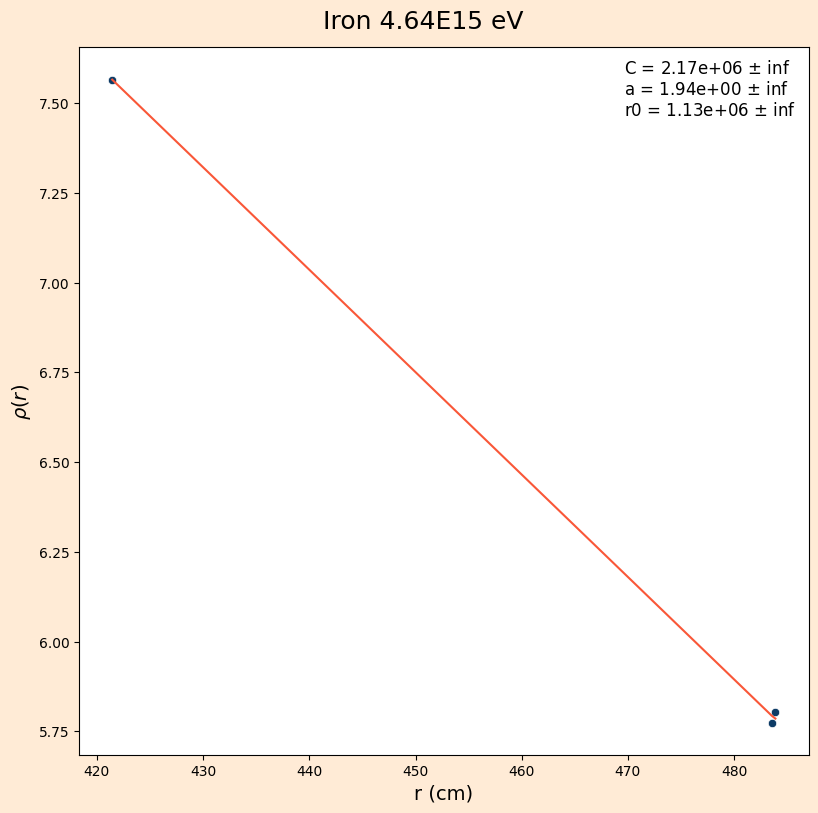

In [13]:
rho = [
    df2['rho1'][0],
    df2['rho2'][0],
    df2['rho3'][0]
]

r_b = [
    df2['r1_b'][0],
    df2['r2_b'][0],
    df2['r3_b'][0]
]
print(rho,r_b)



fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle(str(name) + ' eV', size = 18)
sns.scatterplot(x = r_b, y = rho, ax = ax, color = '#0D3B66')
fig.tight_layout()

ax.set_xlabel('r (cm)', size = 14)
ax.set_ylabel(r'$\rho(r)$', size = 14)

#ax.set_xlim(xmin=0)
#ax.set_ylim(ymin=0)

# Como b varia pouco, vou deixá-lo constante
b = 3
p0 = (5E4,1,1E4)
def f_model(x, c, a, r0):
    return ((c/r0**2)*(x/r0)**(-a)*(1+x/r0)**(-b))

popt, pcov = curve_fit(
    f=f_model,       
    xdata=r_b,   
    ydata=rho,   
    p0=p0,
    maxfev = 2000000
    #sigma=df["Dy"]   
)
c_opt, a_opt, r0_opt = popt

inc = np.sqrt(np.diag(pcov))

y = f_model(r_b,c_opt, a_opt, r0_opt)

plt.plot(r_b, y, color = '#F95738')

ax.legend(title = 'C = {:.2e} $\pm$ {:.2e}\na = {:.2e} $\pm$ {:.2e}\nr0 = {:.2e} $\pm$ {:.2e}'
          .format(c_opt,inc[0],a_opt,inc[1],r0_opt,inc[2]),
          title_fontsize = 12, facecolor = 'white', frameon = False)

plt.savefig('fit_' + str(arquivo) + '.png',bbox_inches = 'tight')

In [14]:
# Energia 

# Parâmetros fóton

k_photon = 1.40E-21
p_photon = 1.68

# Parâmetros próton

k_proton = 5.00E-21
p_proton = 1.63

# Parâmetros ferro

k_iron = 2.58E-10
p_iron = 0.90


E = (c_opt/k_iron)**(1/p_iron)

print('{:e}'.format(E))


4.939015e+17


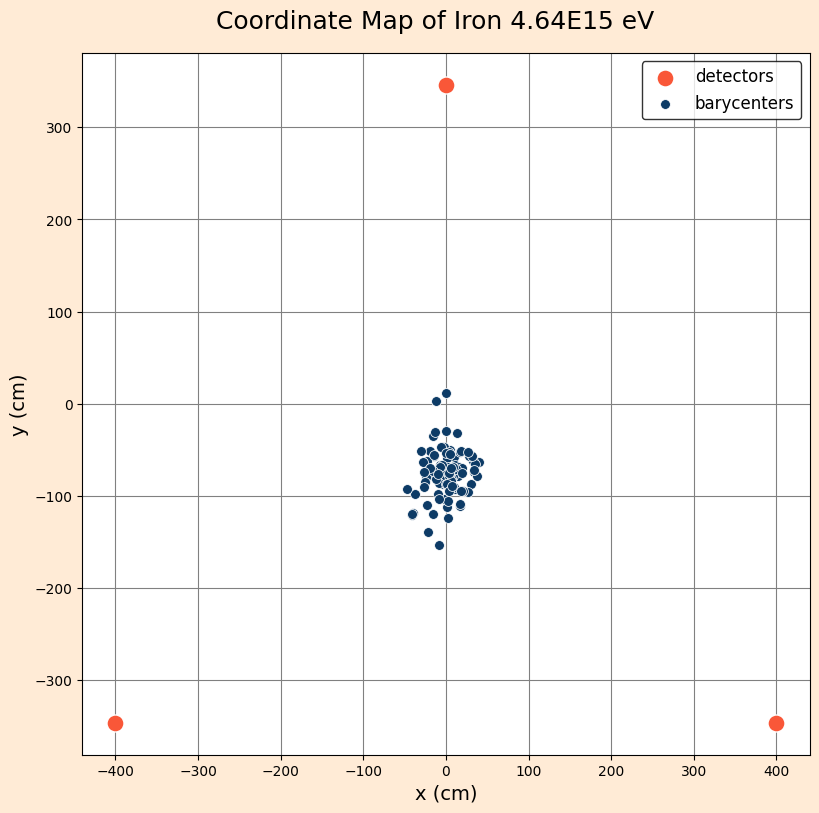

In [15]:
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Coordinate Map of ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

sns.scatterplot(x = [x1[0],x2[0],x3[0]], y = [x1[1],x2[1],x3[1]], ax = ax, color = '#F95738', s = 150)
sns.scatterplot(x = df['x_b'], y = df['y_b'], ax = ax, color = '#0D3B66',s = 50)

ax.set_xlabel('x (cm)', size = 14)
ax.set_ylabel('y (cm)', size = 14)


ax.legend(['detectors', 'barycenters'], edgecolor = 'black', fontsize = 12, loc = 1)

plt.savefig('map_' + str(arquivo) + '.png',bbox_inches = 'tight')